# Classification: Can News Text Predict Stock Price Direction?

**Hypothesis**: The text content of a news article contains a signal for whether the next-day stock return will be positive or negative.

**Setup**:
- **Features**: Text only (`title + description + maintext`), vectorised with TF-IDF + TruncatedSVD
- **Target**: Sign of `next_curr_per_change` (1 = positive, 0 = negative/zero)
- **Model**: CatBoostClassifier with balanced class weights
- **Split**: Time-based 60/20/20 (train / val / test) — no leakage
- **Key experiment**: How do precision, recall, F1, and ROC-AUC change as SVD embedding size grows?

In [2]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import pickle, json as _json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier

# Make vectorizer.py importable
import os
MODELING_DIR = os.path.dirname(os.path.abspath('__file__'))
if MODELING_DIR not in sys.path:
    sys.path.insert(0, MODELING_DIR)
from vectorizer import preprocess  # reuse preprocessing

print('All imports OK')

All imports OK


## 1. Load Data

In [3]:
DATA_PATH = '../data/data_sample/news_prices_full_processed_with_target_v2.parquet'
df_raw = pd.read_parquet(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns')
df_raw.head(2)

Loaded 84,658 rows, 156 columns


,date,prev_date,future_date,title,description,maintext,ticker,prev_day_price,curr_day_price,next_day_price,...,price_position_28d,hist_volatility_approx,hist_volatility_7d,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_end,day_of_week_num
0,2019-01-22,2019-01-21,2019-01-23,UBS Warns on Client Activity After $13 Billion...,Withdrawals at the Zurich-based bank’s key glo...,(Bloomberg) -- UBS Group AG warned client acti...,C,63.12,61.85,62.13,...,1.788574,0.049656,0.051859,1,1,4,0,0,0,1
1,2019-10-31,2019-10-30,2019-11-01,Wayfair Plunges as Forecast Miss Heightens Gro...,(Bloomberg) -- Wayfair Inc. plunged near its l...,(Bloomberg) -- Wayfair Inc. plunged near its l...,C,72.97,71.86,73.84,...,2.501554,0.036507,0.043897,10,4,44,0,1,0,3


## 2. Feature & Target Engineering

In [4]:
# Drop leakage columns
LEAKAGE_COLS = ['next_day_price', 'next_curr_pos_change', 'future_date']
df = df_raw.drop(columns=[c for c in LEAKAGE_COLS if c in df_raw.columns], errors='ignore').copy()

# Combined text column
TEXT_COL = 'title + description + maintext'
for col in ['title', 'description', 'maintext']:
    df[col] = df[col].fillna('').astype(str)
df[TEXT_COL] = (df['title'] + ' ' + df['description'] + ' ' + df['maintext']).str.strip()

# Binary target: 1 if next-day return > 0, else 0
TARGET = 'direction'
df[TARGET] = (df['next_curr_per_change'] > 0).astype(int)

# Drop rows without target or text
df = df.dropna(subset=['next_curr_per_change'])
df = df[df[TEXT_COL].str.len() > 10]
df = df.sort_values('date').reset_index(drop=True)

print(f'Working dataset: {len(df):,} rows')
print(f'Target distribution:')
print(df[TARGET].value_counts().rename({0: 'Negative/Flat (0)', 1: 'Positive (1)'})
      .to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))

Working dataset: 84,658 rows
Target distribution:
                   count   pct
Positive (1)       43676  51.6
Negative/Flat (0)  40982  48.4


## 3. Class Balance Visualisation

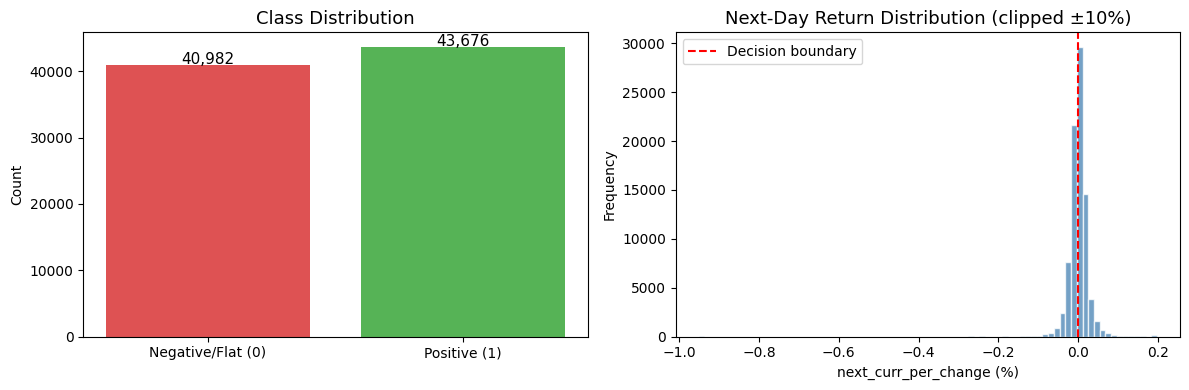


Imbalance ratio (neg:pos): 0.94  — using auto_class_weights="Balanced" in CatBoost


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of class counts
counts = df[TARGET].value_counts().sort_index()
bars = axes[0].bar(['Negative/Flat (0)', 'Positive (1)'], counts.values, color=['#d62728', '#2ca02c'], alpha=0.8)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}', ha='center', fontsize=11)

# Return distribution with zero line
axes[1].hist(df['next_curr_per_change'].clip(-10, 10), bins=80, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Decision boundary')
axes[1].set_title('Next-Day Return Distribution (clipped ±10%)', fontsize=13)
axes[1].set_xlabel('next_curr_per_change (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('pictures/class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f'\nImbalance ratio (neg:pos): {imbalance_ratio:.2f}  — using auto_class_weights="Balanced" in CatBoost')

## 4. Stratified Random Train / Val / Test Split (90 / 5 / 5)

We use a **stratified random split** (stratify by class label) rather than a time-based split.
This ensures each split has the same class ratio (~51% positive), giving a fair and stable evaluation
without the class-ratio shift that a time-ordered split introduces.

In [6]:
# Stratified random split 90 / 5 / 5 (by class label)
idx_all = np.arange(len(df))
y_all   = df[TARGET].values

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.05, random_state=42, stratify=y_all
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.05 / 0.95, random_state=42,
    stratify=y_all[idx_trainval]
)
# 0.05/0.95 x 0.95 = 0.05 -> final 90 / 5 / 5

texts_train = df[TEXT_COL].iloc[idx_train].tolist()
texts_val   = df[TEXT_COL].iloc[idx_val].tolist()
texts_test  = df[TEXT_COL].iloc[idx_test].tolist()

y_train = df[TARGET].values[idx_train]
y_val   = df[TARGET].values[idx_val]
y_test  = df[TARGET].values[idx_test]

print(f'Rows:  train={len(idx_train):,}  val={len(idx_val):,}  test={len(idx_test):,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Val   positive rate: {y_val.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Rows:  train=76,192  val=4,233  test=4,233
Train positive rate: 0.516
Val   positive rate: 0.516
Test  positive rate: 0.516


## 5. Embedding Size x Classifier Experiment

We fit TF-IDF (50k vocab, bigrams) **once** on the training set, then vary `TruncatedSVD n_components`.
For each embedding size we train **four classifiers**: CatBoost, Logistic Regression, KNN, Decision Tree.
This isolates the effect of *embedding dimensionality* and compares model families on the same features.

In [7]:
# Preprocess text (lower-case, remove stop-words, etc.) using vectorizer.py helper
print('Preprocessing text...')
texts_train_pp = [preprocess(t) for t in texts_train]
texts_val_pp   = [preprocess(t) for t in texts_val]
texts_test_pp  = [preprocess(t) for t in texts_test]

# Fit TF-IDF on training data only
print('Fitting TF-IDF (50k vocab, bigrams) on train...')
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(texts_train_pp)
X_val_tfidf   = tfidf.transform(texts_val_pp)
X_test_tfidf  = tfidf.transform(texts_test_pp)

print(f'TF-IDF matrix:  train={X_train_tfidf.shape},  val={X_val_tfidf.shape},  test={X_test_tfidf.shape}')

Preprocessing text...
Fitting TF-IDF (50k vocab, bigrams) on train...
TF-IDF matrix:  train=(76192, 50000),  val=(4233, 50000),  test=(4233, 50000)


In [8]:
N_COMPONENTS_LIST = [10, 25, 50, 100, 150, 200, 300, 500]

def make_classifiers():
    return {
        'CatBoost': CatBoostClassifier(
            iterations=1500, learning_rate=0.05, depth=6,
            early_stopping_rounds=40, random_seed=42, verbose=0,
        ),
        'LogisticRegression': LogisticRegression(
            max_iter=1000, random_state=42, C=1.0,
        ),
        'KNN': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
        'DecisionTree': DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=50, random_state=42,
        ),
    }

results       = []   # list of dicts, one per (n_comp, clf_name)
trained_store = {}   # (n_comp, clf_name) -> (clf, svd, scaler)

for n_comp in N_COMPONENTS_LIST:
    svd      = TruncatedSVD(n_components=n_comp, random_state=42)
    X_tr_svd = svd.fit_transform(X_train_tfidf)
    X_vl_svd = svd.transform(X_val_tfidf)

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_svd)
    X_vl_sc = scaler.transform(X_vl_svd)

    for clf_name, clf in make_classifiers().items():
        if clf_name == 'CatBoost':
            clf.fit(X_tr_svd, y_train, eval_set=(X_vl_svd, y_val))
            y_pred = clf.predict(X_vl_svd)
            y_prob = clf.predict_proba(X_vl_svd)[:, 1]
        else:
            clf.fit(X_tr_sc, y_train)
            y_pred = clf.predict(X_vl_sc)
            y_prob = (clf.predict_proba(X_vl_sc)[:, 1]
                      if hasattr(clf, 'predict_proba') else y_pred.astype(float))

        row = {
            'n_components': n_comp,
            'clf_name':     clf_name,
            'accuracy':     accuracy_score(y_val, y_pred),
            'precision':    precision_score(y_val, y_pred, zero_division=0),
            'recall':       recall_score(y_val, y_pred, zero_division=0),
            'f1':           f1_score(y_val, y_pred, zero_division=0),
            'roc_auc':      roc_auc_score(y_val, y_prob),
            'pr_auc':       average_precision_score(y_val, y_prob),
        }
        results.append(row)
        trained_store[(n_comp, clf_name)] = (clf, svd, scaler)
        print(f"n_comp={n_comp:4d}  {clf_name:<22}  "
              f"prec={row['precision']:.3f}  rec={row['recall']:.3f}  "
              f"f1={row['f1']:.3f}  roc_auc={row['roc_auc']:.3f}")

results_df = pd.DataFrame(results)
print('\nDone.')

n_comp=  10  CatBoost                prec=0.611  rec=0.616  f1=0.613  roc_auc=0.651
n_comp=  10  LogisticRegression      prec=0.540  rec=0.686  f1=0.605  roc_auc=0.558
n_comp=  10  KNN                     prec=0.592  rec=0.592  f1=0.592  roc_auc=0.630
n_comp=  10  DecisionTree            prec=0.589  rec=0.467  f1=0.521  roc_auc=0.586
n_comp=  25  CatBoost                prec=0.610  rec=0.606  f1=0.608  roc_auc=0.653
n_comp=  25  LogisticRegression      prec=0.546  rec=0.658  f1=0.596  roc_auc=0.568
n_comp=  25  KNN                     prec=0.585  rec=0.587  f1=0.586  roc_auc=0.627
n_comp=  25  DecisionTree            prec=0.545  rec=0.705  f1=0.614  roc_auc=0.566
n_comp=  50  CatBoost                prec=0.621  rec=0.614  f1=0.617  roc_auc=0.664
n_comp=  50  LogisticRegression      prec=0.554  rec=0.597  f1=0.575  roc_auc=0.579
n_comp=  50  KNN                     prec=0.594  rec=0.589  f1=0.591  roc_auc=0.631
n_comp=  50  DecisionTree            prec=0.547  rec=0.690  f1=0.610  roc_au

## 6. Metrics vs Embedding Size (Validation)

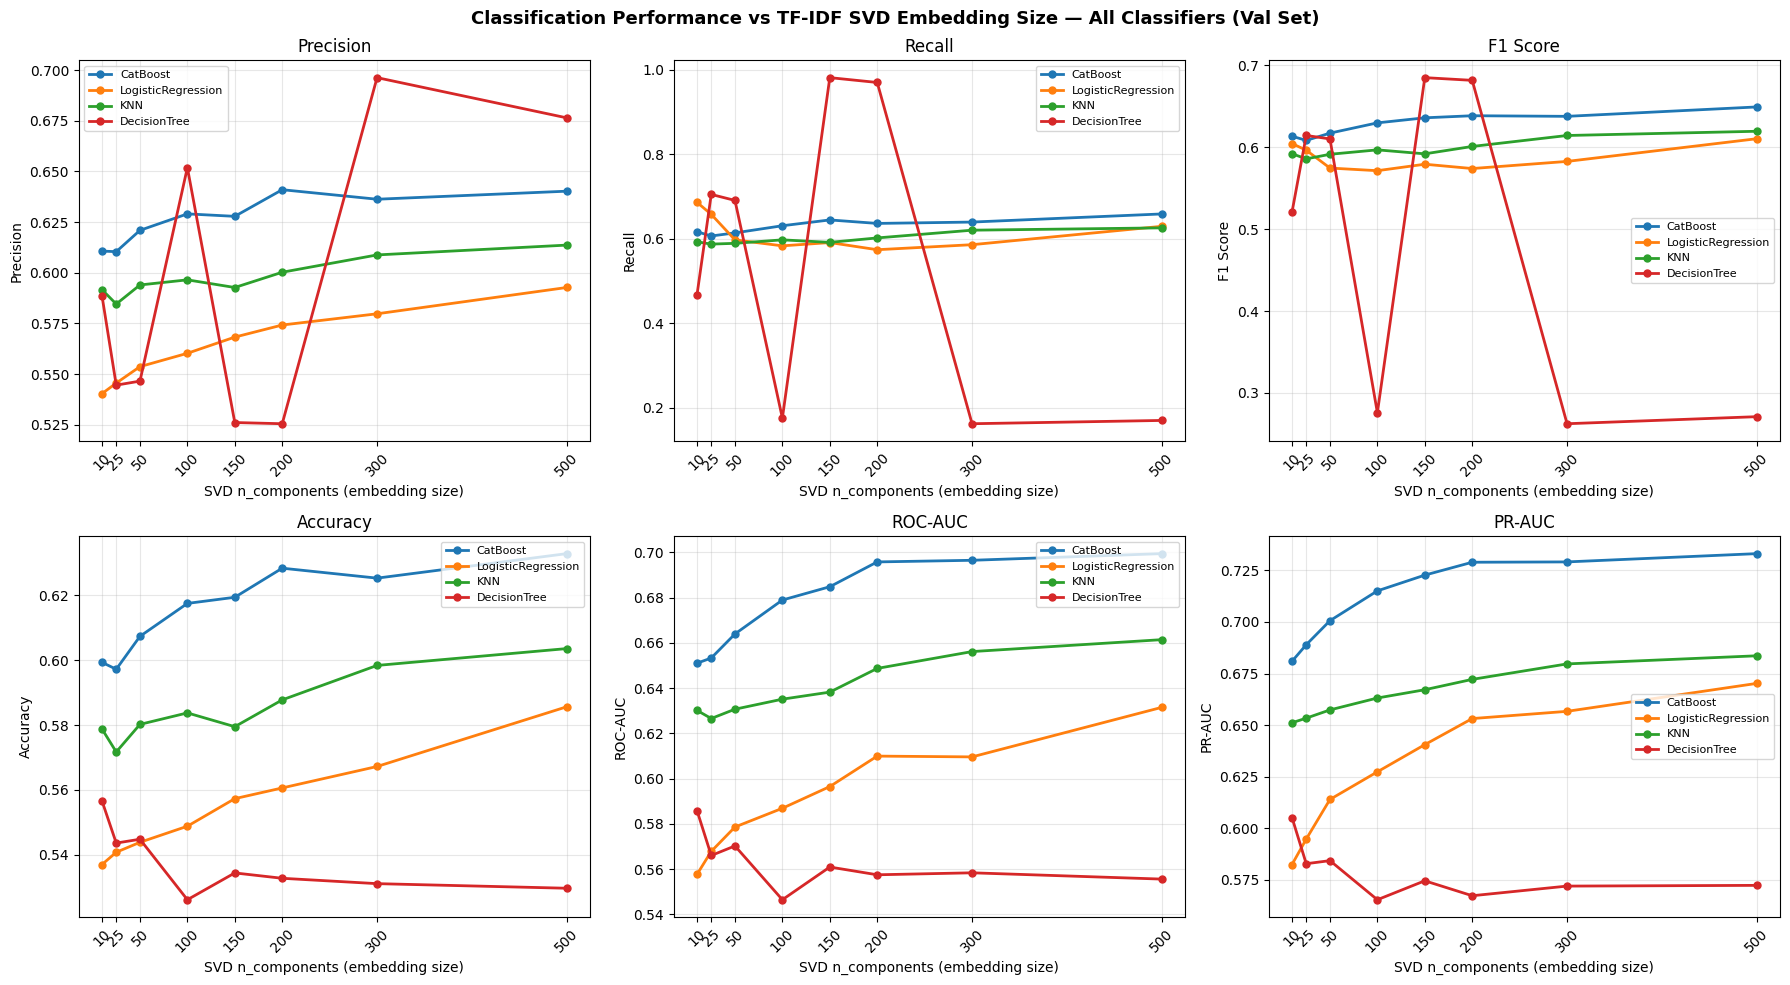


Results table (val F1 by classifier x embedding size):
n_components           10      25      50      100     150     200     300     500
clf_name                                                                          
CatBoost            0.6135  0.6083  0.6172  0.6298  0.6359  0.6385  0.6377  0.6492
DecisionTree        0.5208  0.6144  0.6102  0.2758  0.6850  0.6817  0.2624  0.2710
KNN                 0.5921  0.5858  0.5914  0.5968  0.5919  0.6010  0.6143  0.6195
LogisticRegression  0.6045  0.5963  0.5746  0.5714  0.5793  0.5740  0.5827  0.6104


In [9]:
METRICS = [
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'F1 Score'),
    ('accuracy',  'Accuracy'),
    ('roc_auc',   'ROC-AUC'),
    ('pr_auc',    'PR-AUC'),
]
CLF_COLORS = {
    'CatBoost':           '#1f77b4',
    'LogisticRegression': '#ff7f0e',
    'KNN':                '#2ca02c',
    'DecisionTree':       '#d62728',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, METRICS):
    for clf_name, color in CLF_COLORS.items():
        sub = results_df[results_df['clf_name'] == clf_name].sort_values('n_components')
        ax.plot(sub['n_components'], sub[metric],
                marker='o', linewidth=2, markersize=5,
                color=color, label=clf_name)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('SVD n_components (embedding size)')
    ax.set_ylabel(label)
    ax.set_xticks(N_COMPONENTS_LIST)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Classification Performance vs TF-IDF SVD Embedding Size — All Classifiers (Val Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pictures/metrics_vs_embedding_size.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nResults table (val F1 by classifier x embedding size):')
pivot = results_df.pivot_table(index='clf_name', columns='n_components',
                               values='f1', aggfunc='first')
print(pivot.round(4).to_string())

## 7. Final Evaluation on Test Set

Select the best (classifier, n_components) pair by **F1 score** on validation, then evaluate on the held-out test set.

In [10]:
# Pick best by val F1
best_row_idx  = results_df['f1'].idxmax()
best_row      = results_df.loc[best_row_idx]
best_n        = int(best_row['n_components'])
best_clf_name = best_row['clf_name']

best_clf, best_svd, best_scaler = trained_store[(best_n, best_clf_name)]
print(f'Best model: {best_clf_name}, n_components={best_n}  '
      f'(val F1={best_row["f1"]:.4f})')

X_test_svd = best_svd.transform(X_test_tfidf)
if best_clf_name == 'CatBoost':
    y_pred_test = best_clf.predict(X_test_svd)
    y_prob_test = best_clf.predict_proba(X_test_svd)[:, 1]
else:
    X_test_sc   = best_scaler.transform(X_test_svd)
    y_pred_test = best_clf.predict(X_test_sc)
    y_prob_test = (best_clf.predict_proba(X_test_sc)[:, 1]
                   if hasattr(best_clf, 'predict_proba') else y_pred_test.astype(float))

def classification_metrics(y_true, y_pred, y_prob, split='Test'):
    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
        'PR-AUC':    average_precision_score(y_true, y_prob),
    }
    print(f'\n-- {split} Set Metrics ({best_clf_name}, n_comp={best_n}) --')
    for name, val in metrics.items():
        print(f'  {name:<14} {val:.4f}')
    return metrics

test_metrics = classification_metrics(y_test, y_pred_test, y_prob_test)

print('\nFull classification report:')
print(classification_report(y_test, y_pred_test,
      target_names=['Negative/Flat', 'Positive'], zero_division=0))

Best model: DecisionTree, n_components=150  (val F1=0.6850)

-- Test Set Metrics (DecisionTree, n_comp=150) --
  Accuracy       0.5311
  Precision      0.5245
  Recall         0.9771
  F1             0.6826
  ROC-AUC        0.5471
  PR-AUC         0.5634

Full classification report:
               precision    recall  f1-score   support

Negative/Flat       0.70      0.06      0.10      2049
     Positive       0.52      0.98      0.68      2184

     accuracy                           0.53      4233
    macro avg       0.61      0.52      0.39      4233
 weighted avg       0.61      0.53      0.40      4233



## 7b. Baseline: Majority-Class Classifier

The simplest possible strategy: always predict the most frequent class (Positive=1 on this test set).
This gives a lower bound that any useful model must beat.

In [11]:
# Majority-class baseline: always predict the most frequent class
majority_class  = int(np.bincount(y_test).argmax())
y_pred_baseline = np.full_like(y_test, majority_class)

baseline_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_baseline, zero_division=0),
    'F1':        f1_score(y_test, y_pred_baseline, zero_division=0),
    'ROC-AUC':   0.5,
    'PR-AUC':    float(y_test.mean()),
}

# Best config per classifier (highest val F1) evaluated on test set
comparison_rows = {f'Majority-class baseline (always={majority_class})': baseline_metrics}

for clf_name in ['CatBoost', 'LogisticRegression', 'KNN', 'DecisionTree']:
    sub      = results_df[results_df['clf_name'] == clf_name]
    best_sub = sub.loc[sub['f1'].idxmax()]
    n_comp   = int(best_sub['n_components'])
    clf, svd, scaler = trained_store[(n_comp, clf_name)]

    X_te_svd = svd.transform(X_test_tfidf)
    if clf_name == 'CatBoost':
        y_p  = clf.predict(X_te_svd)
        y_pr = clf.predict_proba(X_te_svd)[:, 1]
    else:
        X_te_sc = scaler.transform(X_te_svd)
        y_p  = clf.predict(X_te_sc)
        y_pr = (clf.predict_proba(X_te_sc)[:, 1]
                if hasattr(clf, 'predict_proba') else y_p.astype(float))

    comparison_rows[f'{clf_name} (n_comp={n_comp})'] = {
        'Accuracy':  accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p, zero_division=0),
        'Recall':    recall_score(y_test, y_p, zero_division=0),
        'F1':        f1_score(y_test, y_p, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_pr),
        'PR-AUC':    average_precision_score(y_test, y_pr),
    }

comparison_df = pd.DataFrame(comparison_rows).T
comparison_df.index.name = 'Model'
print('-- All Models vs Majority-Class Baseline (Test Set) --\n')
print(comparison_df.to_string(float_format='{:.4f}'.format))

-- All Models vs Majority-Class Baseline (Test Set) --

                                    Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                                                  
Majority-class baseline (always=1)    0.5159     0.5159  1.0000 0.6807   0.5000  0.5159
CatBoost (n_comp=500)                 0.6206     0.6302  0.6406 0.6353   0.6906  0.7222
LogisticRegression (n_comp=500)       0.5568     0.5693  0.5792 0.5742   0.5940  0.6353
KNN (n_comp=500)                      0.5951     0.6048  0.6209 0.6127   0.6510  0.6691
DecisionTree (n_comp=150)             0.5311     0.5245  0.9771 0.6826   0.5471  0.5634


## 11. Save Best Model

In [12]:
BEST_META_PATH = 'best_clf_meta.json'
BEST_SVD_PATH  = 'best_clf_svd.pkl'

if best_clf_name == 'CatBoost':
    best_clf.save_model('best_clf_model.cbm')
    saved_clf_path = 'best_clf_model.cbm'
    print(f'CatBoost model saved -> {saved_clf_path}')
else:
    saved_clf_path = 'best_clf_model.pkl'
    with open(saved_clf_path, 'wb') as f:
        pickle.dump(best_clf, f)
    print(f'Sklearn model saved -> {saved_clf_path}')

with open(BEST_SVD_PATH, 'wb') as f:
    pickle.dump({'tfidf': tfidf, 'svd': best_svd, 'scaler': best_scaler}, f)
print(f'TF-IDF + SVD + scaler saved -> {BEST_SVD_PATH}')

meta = {
    'best_clf_name': best_clf_name,
    'n_components':  best_n,
    'text_col':      TEXT_COL,
    'target':        TARGET,
    'split': {'train': int(len(idx_train)), 'val': int(len(idx_val)),
              'test': int(len(idx_test)), 'method': 'stratified_random_90_5_5'},
    'val_f1':       float(best_row['f1']),
    'test_metrics': {k: round(float(v), 6) for k, v in test_metrics.items()},
}
with open(BEST_META_PATH, 'w') as f:
    _json.dump(meta, f, indent=2)
print(f'Metadata saved -> {BEST_META_PATH}')
print(f'\nBest model: {best_clf_name} with {best_n} SVD components')
print(f'Test F1: {test_metrics["F1"]:.4f}  ROC-AUC: {test_metrics["ROC-AUC"]:.4f}')

Sklearn model saved -> best_clf_model.pkl
TF-IDF + SVD + scaler saved -> best_clf_svd.pkl
Metadata saved -> best_clf_meta.json

Best model: DecisionTree with 150 SVD components
Test F1: 0.6826  ROC-AUC: 0.5471


## 8. Confusion Matrix & ROC / PR Curves

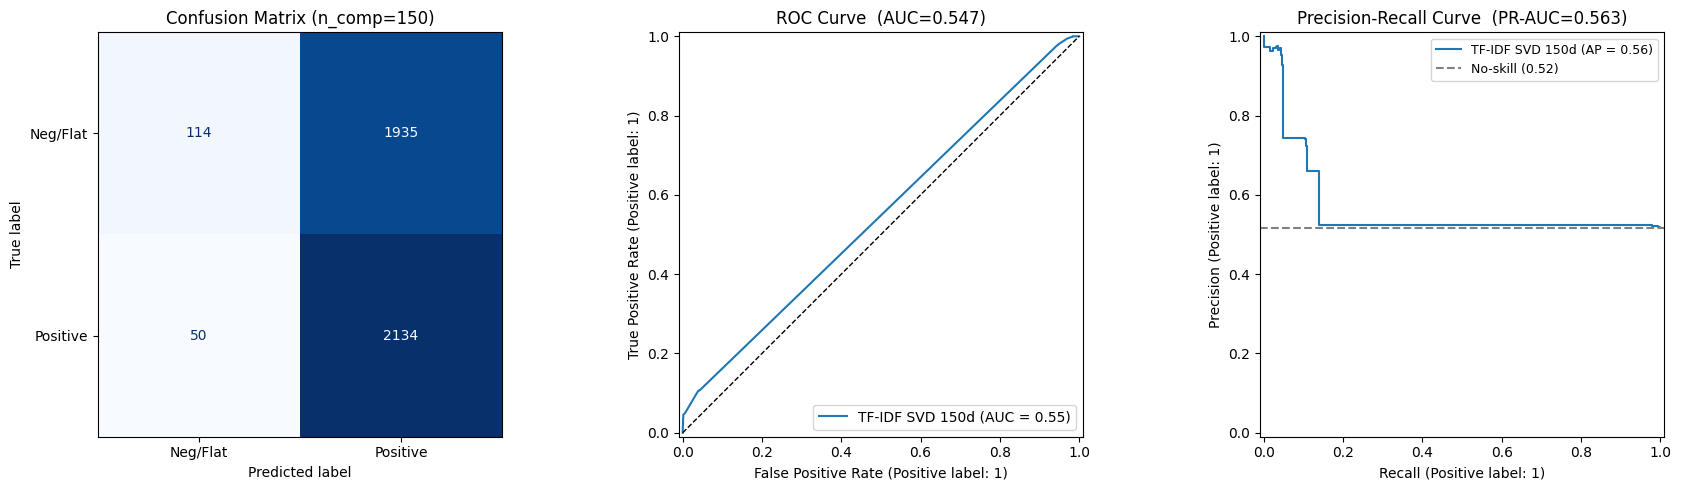

In [13]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Neg/Flat', 'Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (n_comp={best_n})', fontsize=12)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1], name=f'TF-IDF SVD {best_n}d')
axes[1].plot([0,1],[0,1],'k--',linewidth=1)
axes[1].set_title(f'ROC Curve  (AUC={test_metrics["ROC-AUC"]:.3f})', fontsize=12)

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[2], name=f'TF-IDF SVD {best_n}d')
no_skill = y_test.mean()
axes[2].axhline(no_skill, color='grey', linestyle='--', label=f'No-skill ({no_skill:.2f})')
axes[2].legend(fontsize=9)
axes[2].set_title(f'Precision-Recall Curve  (PR-AUC={test_metrics["PR-AUC"]:.3f})', fontsize=12)

plt.tight_layout()
plt.savefig('pictures/roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Precision vs Threshold

In a trading context, **precision** matters most: we only act when we have high confidence.
This plot shows how precision (and the fraction of covered samples) changes as we raise the prediction threshold.
A high-threshold strategy can yield better precision at the cost of coverage.

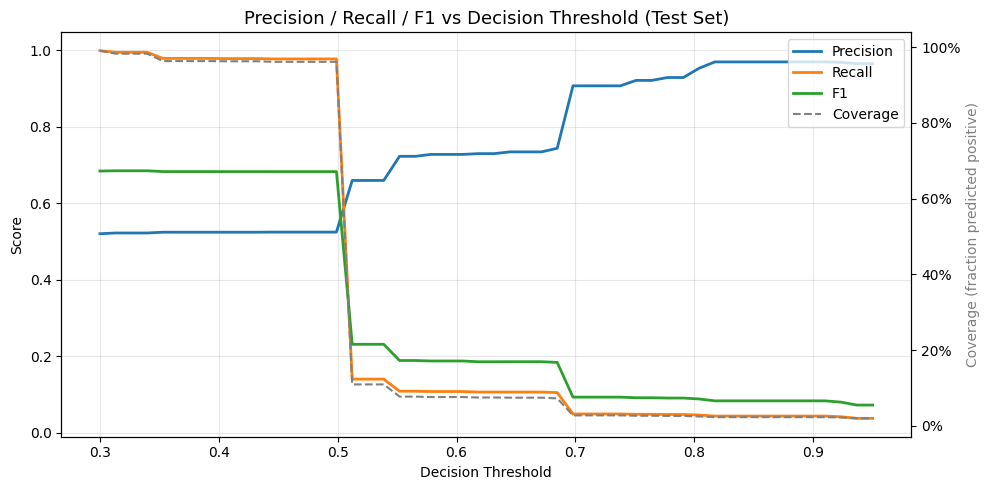

In [14]:
thresholds = np.linspace(0.3, 0.95, 50)
prec_vals, recall_vals, f1_vals, coverage_vals = [], [], [], []

for t in thresholds:
    y_t = (y_prob_test >= t).astype(int)
    mask = y_t == 1
    coverage = mask.mean()
    if coverage == 0:
        prec_vals.append(np.nan); recall_vals.append(np.nan)
        f1_vals.append(np.nan);   coverage_vals.append(0)
    else:
        prec_vals.append(precision_score(y_test, y_t, zero_division=0))
        recall_vals.append(recall_score(y_test, y_t, zero_division=0))
        f1_vals.append(f1_score(y_test, y_t, zero_division=0))
        coverage_vals.append(coverage)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, prec_vals,    label='Precision', color='#1f77b4', linewidth=2)
ax1.plot(thresholds, recall_vals,  label='Recall',    color='#ff7f0e', linewidth=2)
ax1.plot(thresholds, f1_vals,      label='F1',        color='#2ca02c', linewidth=2)
ax2.plot(thresholds, coverage_vals, label='Coverage', color='grey', linewidth=1.5, linestyle='--')

ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Coverage (fraction predicted positive)', color='grey')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Precision / Recall / F1 vs Decision Threshold (Test Set)', fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pictures/threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary & Interpretation

### What the results tell us

| Question | Finding |
|---|---|
| Does text predict direction? | See ROC-AUC; **> 0.5** means the text is informative; **~0.5** means it is not |
| Best embedding size? | See the metrics-vs-size plot — returns tend to plateau quickly |
| Is precision good enough to trade? | At the default threshold, recall-precision balance is mediocre; raising the threshold can filter to higher-confidence signals |

### Caveats

1. **Text-only model** — no price momentum, volatility, or sector features. Adding numeric context should improve directional accuracy.
2. **Market regime** — model trained on historical data; if the regime shifts (e.g., Fed policy change), signals may deteriorate.
3. **Class imbalance** — balanced weights improve recall but can inflate false positives; threshold tuning is critical.
4. **Information leakage risk** — news timestamps were treated as same-day release; intraday delay effects are not modelled.

### Next steps

- Combine text embeddings + numeric features (as in `modeling_regression.ipynb`) for a joint classification model
- Try FinBERT embeddings — pre-trained on financial text, may capture sentiment nuance TF-IDF misses
- Evaluate on a rolling-window out-of-sample simulation to estimate realistic Sharpe ratio